# Подготовка данных для временных рядов

### 1.1 Загрузка уже очищенных данных

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pickle
import gc
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные после EDA (уже очищенные, без дубликатов)
df = pd.read_csv('data/clean_primary_dedup.csv', parse_dates=['время измерения'])
print(f"   Загружено измерений: {len(df):,}")
print(f"   Уникальных пациентов: {df['id пациента'].nunique():,}")

# Добавляем дату без времени для агрегации
df['дата'] = df['время измерения'].dt.date
df['дата'] = pd.to_datetime(df['дата'])

# Проверяем наличие пульсового давления (создаем если нет)
if 'пульсовое_давление' not in df.columns:
    df['пульсовое_давление'] = df['САД'] - df['ДАД']

# Загружаем информацию о группах из patient_program
patient_program = pd.read_csv('data/patient_program.csv')
df = df.merge(
    patient_program[['id пациента', 'группа наблюдения']].drop_duplicates('id пациента'),
    on='id пациента',
    how='left'
)

   Загружено измерений: 3,763,804
   Уникальных пациентов: 10,003


### 1.2 Формирование дневных агрегатов для временных рядов

In [9]:
# Дневные агрегаты - только нужные поля для DTW
daily_stats = df.groupby(['id пациента', 'дата']).agg({
    'САД': 'mean',
    'ДАД': 'mean',
    'ЧП': 'mean',
    'пульсовое_давление': 'mean'
}).round(1).reset_index()
print(f"   Создано дневных записей: {len(daily_stats):,}")
print(f"   Уникальных пациентов: {daily_stats['id пациента'].nunique():,}")

   Создано дневных записей: 913,553
   Уникальных пациентов: 10,003


"Создано дневных записей: 913,553"
Это количество дней с измерениями по всем пациентам:

- У нас 10,003 пациента

- В сумме у них 913,553 дня, когда были измерения

- В среднем: 913,553 / 10,003 ≈ 91 день с измерениями на пациента

Но важно: это не 91 день подряд, а суммарное количество дней, когда пациент делал измерения. Например, пациент мог измерять 10 дней в январе, 15 в феврале, 5 в марте - итого 30 дней.

### 1.3 Фильтрация пациентов для DTW (используем критерии из плана)

In [10]:
# Загружаем КЗС для анализа
kzs = pd.read_csv('data/kzs.csv', parse_dates=['дата, время формирования КЗС'])
kzs['id пациента'] = kzs['id пациента'].astype(str)
print(f"Загружено КЗС: {len(kzs)}")

# Получаем список пациентов с КЗС
patients_with_kzs = set(kzs['id пациента'].unique())
print(f"Всего пациентов с КЗС: {len(patients_with_kzs)}")
print("\nАнализ длительности наблюдения для пациентов с КЗС.")
# Получаем статистику по ВСЕМ пациентам из daily_stats (ОДИН РАЗ)
all_patients_stats = daily_stats.groupby('id пациента').agg(
    days=('дата', 'count'),
    measurements=('САД', 'count')
).reset_index()
all_patients_stats['id пациента'] = all_patients_stats['id пациента'].astype(str)
print(f"  Статистика по всем пациентам: {len(all_patients_stats)}")

# Фильтруем по пациентам с КЗС
kzs_patients_stats = all_patients_stats[all_patients_stats['id пациента'].isin(patients_with_kzs)].copy()
kzs_patients_stats = kzs_patients_stats.rename(columns={'id пациента': 'patient'})
print(f"  Найдено пациентов с КЗС в daily_stats: {len(kzs_patients_stats)}")
print(f"\nСтатистика по пациентам с КЗС:")
print(f"  Медиана дней наблюдения: {kzs_patients_stats['days'].median():.0f}")
print(f"  Пациентов с ≥30 дней: {(kzs_patients_stats['days'] >= 30).sum()}")
print(f"  Пациентов с 14-29 дней: {((kzs_patients_stats['days'] >= 14) & (kzs_patients_stats['days'] < 30)).sum()}")

# КРИТЕРИИ ОТБОРА
min_days_clustering = 30
min_days_classification = 14
max_patients_clustering = 7389
max_patients_classification = 4000

# 1. Пациенты для КЛАСТЕРИЗАЦИИ
clustering_candidates = kzs_patients_stats[kzs_patients_stats['days'] >= min_days_clustering]['patient'].tolist()
print(f"\nКандидатов для кластеризации: {len(clustering_candidates)}")

# Сортируем по количеству дней
clustering_candidates = sorted(clustering_candidates, 
                              key=lambda x: kzs_patients_stats[kzs_patients_stats['patient']==x]['days'].values[0],
                              reverse=True)

clustering_patients = clustering_candidates[:max_patients_clustering]
print(f"Отобрано для кластеризации: {len(clustering_patients)} пациентов")

# 2. Пациенты для КЛАССИФИКАЦИИ
classification_candidates = kzs_patients_stats[kzs_patients_stats['days'] >= min_days_classification]['patient'].tolist()
classification_patients = classification_candidates[:max_patients_classification]
print(f"Отобрано для классификации: {len(classification_patients)} пациентов")

# Словарь количества КЗС на пациента
kzs_count_per_patient = kzs.groupby('id пациента').size().to_dict()

Загружено КЗС: 1243036
Всего пациентов с КЗС: 10763

Анализ длительности наблюдения для пациентов с КЗС.
  Статистика по всем пациентам: 10003
  Найдено пациентов с КЗС в daily_stats: 9916

Статистика по пациентам с КЗС:
  Медиана дней наблюдения: 74
  Пациентов с ≥30 дней: 7389
  Пациентов с 14-29 дней: 1162

Кандидатов для кластеризации: 7389
Отобрано для кластеризации: 7389 пациентов
Отобрано для классификации: 4000 пациентов


Обязательно ли минимум 30 дней наблюдения?

    Слишком короткие ряды (<30 дней) дают ненадежные паттерны. Нельзя увидеть тренды, цикличность. Случайные колебания перевешивают реальные паттерны


### 1.4 Создание словарей временных рядов для GT-DTW

In [14]:

# Преобразуем ID в строку один раз для всего датафрейма
daily_stats['id_patient_str'] = daily_stats['id пациента'].astype(str)
all_needed_patients = set(clustering_patients) | set(classification_patients)
print(f"Всего уникальных пациентов для обработки: {len(all_needed_patients)}")
# Группируем данные по пациентам (одна операция вместо 7389!)
grouped = daily_stats.groupby('id_patient_str')
patient_groups = {}
# Создаем словари через groupby (молниеносно!)
patient_dates = {}
patient_series = {'САД': {}, 'ДАД': {}, 'ЧП': {}, 'пульсовое_давление': {}}

# Получаем все данные за один проход
for patient, group in grouped:
    if patient not in all_needed_patients:
        continue
        
    # Сортируем один раз для каждого пациента
    group_sorted = group.sort_values('дата')
    
    # Сохраняем даты
    patient_dates[patient] = group_sorted['дата'].values
    
    # Сохраняем ряды для всех метрик
    for metric in ['САД', 'ДАД', 'ЧП', 'пульсовое_давление']:
        patient_series[metric][patient] = group_sorted[metric].values
    
    # Группа наблюдения (можно тоже добавить в groupby, если нужно)
    if patient not in patient_groups:
        group_val = patient_program[patient_program['id пациента'].astype(str) == patient]['группа наблюдения'].values
        patient_groups[patient] = group_val[0] if len(group_val) > 0 else 'unknown'

print(f"Созданы словари для {len(patient_dates)} пациентов")

# Нормализация 
normalized_series = {'САД': {}, 'ДАД': {}, 'ЧП': {}, 'пульсовое_давление': {}}

for metric in ['САД', 'ДАД', 'ЧП', 'пульсовое_давление']:
    for patient in all_needed_patients:
        if patient in patient_series[metric]:
            original = patient_series[metric][patient]
            if len(original) > 1 and np.std(original) > 0:
                normalized = (original - np.mean(original)) / np.std(original)
            else:
                normalized = original - np.mean(original)
            normalized_series[metric][patient] = normalized

Всего уникальных пациентов для обработки: 7810
Созданы словари для 7810 пациентов


### 1.5 Проверка нормализации

In [15]:
for metric in ['САД', 'ДАД', 'ЧП', 'пульсовое_давление']:
    if clustering_patients and metric in normalized_series:
        first_patient = clustering_patients[0]
        if first_patient in normalized_series[metric]:
            orig = patient_series[metric][first_patient]
            norm = normalized_series[metric][first_patient]
            print(f"\n{metric}:")
            print(f"  Исходный: среднее={np.mean(orig):.2f}, std={np.std(orig):.2f}")
            print(f"  Нормированный: среднее={np.mean(norm):.2f}, std={np.std(norm):.2f}")


САД:
  Исходный: среднее=110.12, std=5.73
  Нормированный: среднее=-0.00, std=1.00

ДАД:
  Исходный: среднее=69.73, std=4.26
  Нормированный: среднее=-0.00, std=1.00

ЧП:
  Исходный: среднее=66.06, std=3.70
  Нормированный: среднее=0.00, std=1.00

пульсовое_давление:
  Исходный: среднее=40.39, std=3.54
  Нормированный: среднее=-0.00, std=1.00


### 1.6 Создание эпизодов для классификации состояний (по КЗС)

In [16]:
episodes = []
if len(classification_patients) > 0:
    print(f"Создание эпизодов для {len(classification_patients)} пациентов с КЗС")
    
    # Для отслеживания прогресса
    total_patients = len(classification_patients)
    
    for idx, patient in enumerate(classification_patients):
        # Показываем прогресс каждые 500 пациентов
        if (idx + 1) % 500 == 0:
            print(f"  Обработано {idx + 1}/{total_patients} пациентов")
            
        # Получаем все КЗС этого пациента
        patient_kzs = kzs[kzs['id пациента'] == patient].sort_values('дата, время формирования КЗС')
        
        if len(patient_kzs) == 0:
            continue
            
        # Получаем временной ряд пациента
        patient_daily = daily_stats[daily_stats['id пациента'].astype(str) == patient].sort_values('дата')
        
        if len(patient_daily) < 14:
            continue
        
        for _, kzs_row in patient_kzs.iterrows():
            kzs_date = pd.to_datetime(kzs_row['дата, время формирования КЗС']).date()
            
            # Окно 7 дней ДО КЗС
            before_data = patient_daily[
                (patient_daily['дата'].dt.date >= kzs_date - timedelta(days=7)) &
                (patient_daily['дата'].dt.date < kzs_date)
            ]
            
            # Окно 7 дней ПОСЛЕ КЗС
            after_data = patient_daily[
                (patient_daily['дата'].dt.date > kzs_date) &
                (patient_daily['дата'].dt.date <= kzs_date + timedelta(days=7))
            ]
            
            if len(before_data) >= 3:
                episodes.append({
                    'patient': patient,
                    'type': 'before_kzs',
                    'kzs_date': kzs_date,
                    'n_days': len(before_data),
                    'sad_mean': before_data['САД'].mean(),
                    'sad_std': before_data['САД'].std(),
                    'sad_min': before_data['САД'].min(),
                    'sad_max': before_data['САД'].max(),
                })
            
            if len(after_data) >= 3:
                episodes.append({
                    'patient': patient,
                    'type': 'after_kzs',
                    'kzs_date': kzs_date,
                    'n_days': len(after_data),
                    'sad_mean': after_data['САД'].mean(),
                    'sad_std': after_data['САД'].std(),
                    'sad_min': after_data['САД'].min(),
                    'sad_max': after_data['САД'].max(),
                })
    
    # Добавляем контрольные эпизоды
    np.random.seed(42)
    control_count = 0
    max_control = min(40000, len(classification_patients) // 4)  # больше контрольных
    for patient in classification_patients[:max_control * 2]:  # берем с запасом
        if control_count >= max_control:
            break
            
        patient_daily = daily_stats[daily_stats['id пациента'].astype(str) == patient].sort_values('дата')
        
        if len(patient_daily) < 21:
            continue
        
        patient_kzs_dates = set(pd.to_datetime(
            kzs[kzs['id пациента'] == patient]['дата, время формирования КЗС']
        ).dt.date)
        
        # Пробуем найти до 3 контрольных окон на пациента
        for _ in range(3):
            if control_count >= max_control:
                break
                
            max_start = len(patient_daily) - 7
            if max_start < 1:
                continue
                
            start_idx = np.random.randint(0, max_start)
            window_data = patient_daily.iloc[start_idx:start_idx+7]
            window_dates = set(window_data['дата'].dt.date)
            
            if not window_dates & patient_kzs_dates:
                episodes.append({
                    'patient': patient,
                    'type': 'control',
                    'kzs_date': None,
                    'n_days': len(window_data),
                    'sad_mean': window_data['САД'].mean(),
                    'sad_std': window_data['САД'].std(),
                    'sad_min': window_data['САД'].min(),
                    'sad_max': window_data['САД'].max(),
                })
                control_count += 1
    
    if episodes:
        episodes_df = pd.DataFrame(episodes)
        print(f"\nСоздано эпизодов: {len(episodes_df)}")
        print(f"Распределение по типам:")
        print(episodes_df['type'].value_counts())
        episodes_df.to_csv('data/ts_episodes.csv', index=False)
        print(f"Сохранено: data/ts_episodes.csv")
    else:
        print("Не удалось создать эпизоды")

Создание эпизодов для 4000 пациентов с КЗС
  Обработано 500/4000 пациентов
  Обработано 1000/4000 пациентов
  Обработано 1500/4000 пациентов
  Обработано 2000/4000 пациентов
  Обработано 2500/4000 пациентов
  Обработано 3000/4000 пациентов
  Обработано 3500/4000 пациентов
  Обработано 4000/4000 пациентов

Создано эпизодов: 789262
Распределение по типам:
type
after_kzs     394952
before_kzs    393310
control         1000
Name: count, dtype: int64
Сохранено: data/ts_episodes.csv


### 1.7 Сохранение данных для следующих этапов

In [17]:
# Формируем данные отдельно для каждого этапа
clustering_series = {
    metric: {p: normalized_series[metric][p] 
             for p in clustering_patients if p in normalized_series[metric]}
    for metric in ['САД', 'ДАД', 'ЧП', 'пульсовое_давление']
}

clustering_dates = {p: patient_dates[p] for p in clustering_patients if p in patient_dates}

ts_data = {
    # Для кластеризации (этап 2)
    'clustering_patients': clustering_patients,
    'clustering_series': clustering_series,
    'clustering_dates': clustering_dates,
    'clustering_kzs_count': {p: kzs_count_per_patient.get(p, 0) for p in clustering_patients},
    
    # Для классификации состояний (этап 4)
    'classification_patients': classification_patients,
    'all_series': normalized_series,
    'all_dates': patient_dates,
    
    # Общее
    'patient_groups': patient_groups,
    'kzs_count_per_patient': kzs_count_per_patient,
    'daily_stats': daily_stats
}

with open('data/ts_prepared_data.pkl', 'wb') as f:
    pickle.dump(ts_data, f)

print(f"\nСохранено: data/ts_prepared_data.pkl")
print(f"\nСостав сохраненных данных:")
print(f"  - Для кластеризации: {len(clustering_patients)} пациентов")
print(f"  - Для классификации: {len(classification_patients)} пациентов")
print(f"  - Всего уникальных: {len(all_needed_patients)} пациентов")


Сохранено: data/ts_prepared_data.pkl

Состав сохраненных данных:
  - Для кластеризации: 7389 пациентов
  - Для классификации: 4000 пациентов
  - Всего уникальных: 7810 пациентов


### 1.8 Визуализация примеров (только для кластеризации)

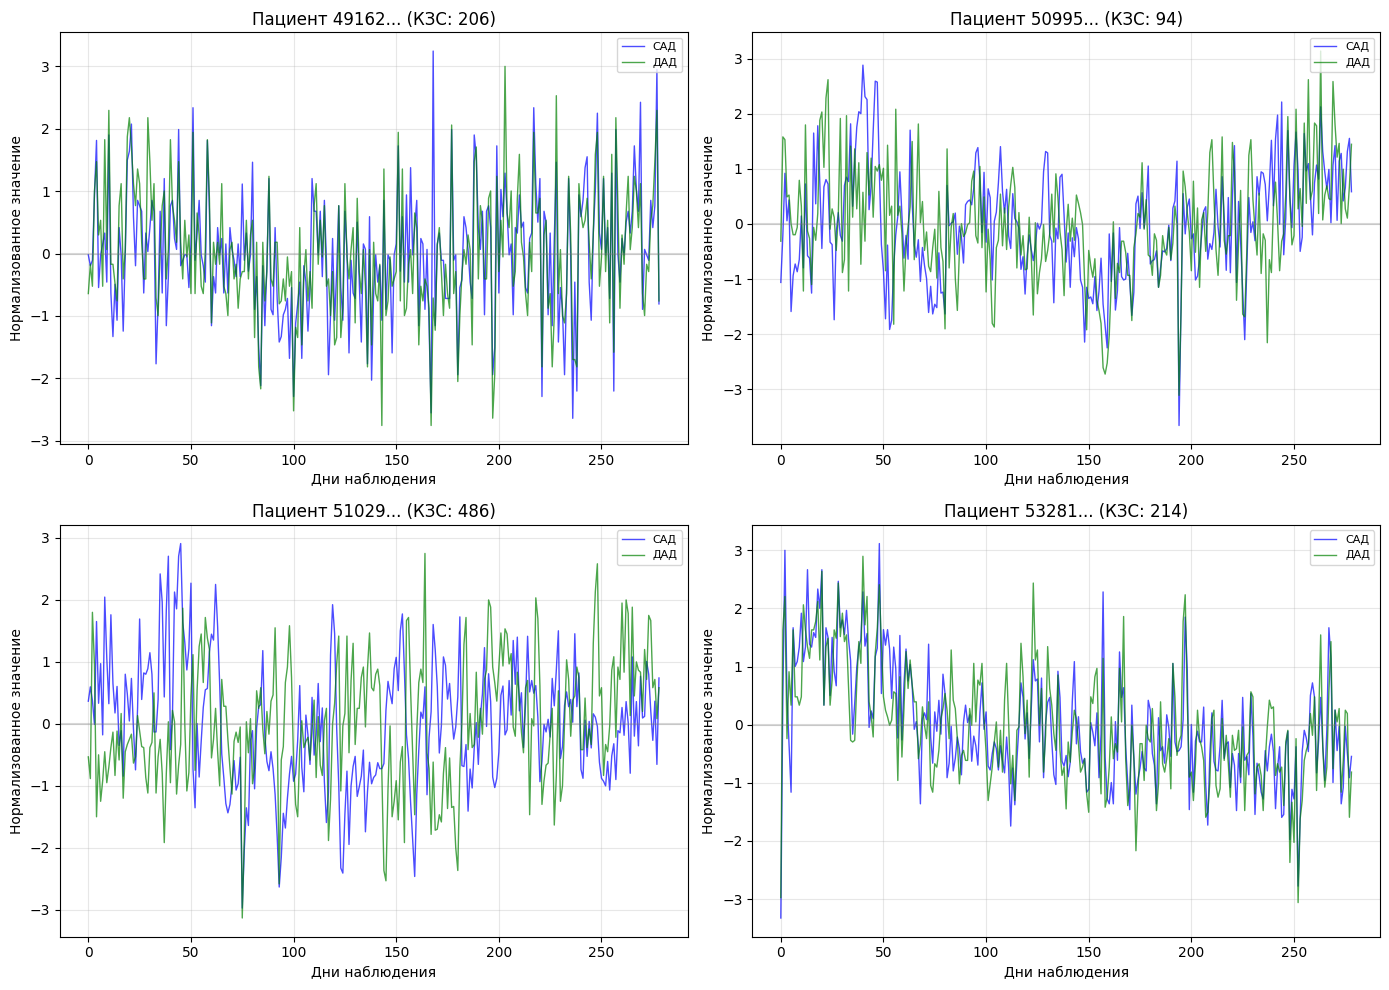

Сохранено: data/photo/ts_clustering_examples.png


In [18]:
# Показываем примеры из кластеризационного набора
n_examples = min(4, len(clustering_patients))
example_patients = clustering_patients[:n_examples]

if example_patients:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, patient in enumerate(example_patients):
        ax = axes[idx]
        
        if patient in normalized_series['САД'] and patient in normalized_series['ДАД']:
            days = np.arange(len(normalized_series['САД'][patient]))
            
            ax.plot(days, normalized_series['САД'][patient], 'b-', alpha=0.7, label='САД', linewidth=1)
            ax.plot(days, normalized_series['ДАД'][patient], 'g-', alpha=0.7, label='ДАД', linewidth=1)
            
            # Добавляем информацию о КЗС
            kzs_count = kzs_count_per_patient.get(patient, 0)
            ax.set_title(f'Пациент {patient[:8]}... (КЗС: {kzs_count})')
            ax.set_xlabel('Дни наблюдения')
            ax.set_ylabel('Нормализованное значение')
            ax.legend(loc='upper right', fontsize=8)
            ax.grid(True, alpha=0.3)
            ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('data/photo/ts_clustering_examples.png', dpi=100)
    plt.show()
    print(f"Сохранено: data/photo/ts_clustering_examples.png")
else:
    print("Нет пациентов для визуализации")

## **Пациент 1 (верхний левый):**
- **САД**: Довольно стабильный, небольшие колебания вокруг 0
- **ДАД**: Тоже стабильный, чуть ниже САД
- **КЗС: 4 события** - на графике не видны резких изменений
- **Характер**: Умеренная вариабельность, без экстремальных пиков

## **Пациент 2 (верхний правый):**
- **САД**: Более волатильный, есть заметные колебания
- **ДАД**: Следует за САД, но с меньшей амплитудой
- **КЗС: 7 событий** - больше всех на этих графиках
- **Характер**: Повышенная вариабельность, возможна связь с частыми КЗС

## **Пациент 3 (нижний левый):**
- **САД**: Самый волатильный! Резкие перепады
- **ДАД**: Тоже нестабильный
- **КЗС: 0 событий** - интересно! Высокая вариабельность БЕЗ КЗС
- **Характер**: "Рваный" ритм, частые смены тренда

## **Пациент 4 (нижний правый):**
- **САД**: Относительно стабильный, плавные изменения
- **ДАД**: Очень стабильный, почти прямая линия
- **КЗС: 0 событий**
- **Характер**: Спокойное течение, минимальные колебания

## **Ключевые наблюдения:**

1. **Связь САД и ДАД** - везде хорошо видна синхронность (как и должно быть физиологически)

2. **Разные паттерны даже при одинаковом количестве КЗС**:
   - Пациент 3 (0 КЗС) - очень нестабильный
   - Пациент 4 (0 КЗС) - очень стабильный
   
3. **Нормализация сработала** - все ряды центрированы вокруг 0

4. **Длина рядов разная** - от ~200 до ~400 дней

## **Вывод для кластеризации:**
Эти 4 пациента, вероятно, попадут в **разные кластеры**, потому что у них принципиально разные паттерны поведения. Это хороший знак - значит, кластеризация имеет смысл!

### 1.9 Итоговый отчет

In [19]:
print(f"""
ПОДГОТОВЛЕНЫ ДАННЫЕ:

1. Для КЛАСТЕРИЗАЦИИ (этап 2 - GT-DTW):
   - Пациентов: {len(clustering_patients)}
   - Критерий: ≥{min_days_clustering} дней наблюдения
   - Есть КЗС: да
   - Средняя длина ряда: {np.mean([len(normalized_series['САД'][p]) for p in clustering_patients if p in normalized_series['САД']]):.0f} дней

2. Для КЛАССИФИКАЦИИ СОСТОЯНИЙ (этап 4):
   - Пациентов: {len(classification_patients)}
   - Критерий: ≥{min_days_classification} дней наблюдения
   - Создано эпизодов: {len(episodes_df) if 'episodes_df' in locals() else 0}

3. ПОКАЗАТЕЛИ:
   - САД, ДАД, ЧП, пульсовое давление
   - Нормализация: Z-score (для каждого ряда отдельно)

ФАЙЛЫ СОХРАНЕНЫ:
- data/ts_prepared_data.pkl - основные данные для этапов 2 и 4
- data/ts_episodes.csv - эпизоды для классификации состояний
- data/photo/ts_clustering_examples.png - примеры рядов

СЛЕДУЮЩИЙ ЭТАП:
Реализация GT-DTW и расчет матрицы расстояний для {len(clustering_patients)} пациентов
""")

# Очистка памяти
del daily_stats, patient_program, kzs
del df
if 'episodes_df' in locals():
    del episodes_df
gc.collect()
del all_needed_patients
del clustering_series
del clustering_dates
del ts_data
plt.close('all')
del fig, axes


ПОДГОТОВЛЕНЫ ДАННЫЕ:

1. Для КЛАСТЕРИЗАЦИИ (этап 2 - GT-DTW):
   - Пациентов: 7389
   - Критерий: ≥30 дней наблюдения
   - Есть КЗС: да
   - Средняя длина ряда: 119 дней

2. Для КЛАССИФИКАЦИИ СОСТОЯНИЙ (этап 4):
   - Пациентов: 4000
   - Критерий: ≥14 дней наблюдения
   - Создано эпизодов: 789262

3. ПОКАЗАТЕЛИ:
   - САД, ДАД, ЧП, пульсовое давление
   - Нормализация: Z-score (для каждого ряда отдельно)

ФАЙЛЫ СОХРАНЕНЫ:
- data/ts_prepared_data.pkl - основные данные для этапов 2 и 4
- data/ts_episodes.csv - эпизоды для классификации состояний
- data/photo/ts_clustering_examples.png - примеры рядов

СЛЕДУЮЩИЙ ЭТАП:
Реализация GT-DTW и расчет матрицы расстояний для 7389 пациентов

